# Claims Routing & Loss Severity Modeling - Phoenix Financial
We're building two models here:
1. **Severity model** - predicts expected repair cost for a claim.
2. **Garage choice model** - predicts the probability that an insured picks a given garage out of the candidate set available for their vehicle's manufacturer.

This step loads the three source tables, does an initial pass over structure and quality, flags the data issues called out in the data dictionary, and produces a cleaned version of `claims` to build on in modeling part.

## Imports

In [16]:
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

## Loading the data

In [17]:
# csv
claims = pd.read_csv("data/claims.csv")
garages = pd.read_csv("data/garages.csv")
potential = pd.read_csv("data/potential_garages_by_manufacturer.csv")

# json
with open("data/data_dictionary.json", encoding="utf-8") as f:
    raw_dict_text = f.read()
data_dict = json.loads(re.sub(r",(\s*[}\]])", r"\1", raw_dict_text))

# dims
print(f"claims:    {claims.shape}")
print(f"garages:   {garages.shape}")
print(f"potential: {potential.shape}")

claims:    (2000, 22)
garages:   (150, 8)
potential: (2500, 2)


## Quick overview

Column types, missing values, a look at a few rows per table.

In [18]:
claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   claim_id                  2000 non-null   int64  
 1   insured_id                2000 non-null   int64  
 2   agent_id                  2000 non-null   int64  
 3   opened_by                 2000 non-null   str    
 4   car_manufacturer          2000 non-null   str    
 5   car_model                 2000 non-null   str    
 6   vehicle_year              2000 non-null   int64  
 7   vehicle_age               2000 non-null   int64  
 8   vehicle_value_nis         2000 non-null   int64  
 9   driver_age                2000 non-null   int64  
 10  damage_type               2000 non-null   str    
 11  partial_damage_ind        2000 non-null   int64  
 12  insured_city_id           2000 non-null   int64  
 13  insured_city_name         2000 non-null   str    
 14  insured_lat        

In [19]:
claims.head(5)

,claim_id,insured_id,agent_id,opened_by,car_manufacturer,car_model,vehicle_year,vehicle_age,vehicle_value_nis,driver_age,damage_type,partial_damage_ind,insured_city_id,insured_city_name,insured_lat,insured_lon,insured_city_type,insured_city_ses_cluster,event_date,open_date,chosen_garage_id,damage_cost_nis
0,1,42855942,79,insured,Honda,HON_4,2021,4,57099,52,mechanical,1,26,LOC_026,NaN,NaN,urban,6,26/10/2024,27/10/2024,30,3029.00
1,2,96761110,40,insured,Subaru,SUB_4,2024,1,75693,47,mechanical,1,58,LOC_058,30.960868,35.626638,suburban,5,15/06/2025,19/06/2025,37,12793.47
2,3,29906232,112,insured,Mercedes,MER_5,2015,10,66452,37,collision,1,63,LOC_063,32.104333,35.735960,suburban,5,13/05/2024,26/05/2024,90,3000.00
3,4,81232748,14,insured,Mitsubishi,MIT_1,2014,11,51313,25,other,1,80,LOC_080,30.060021,35.142194,suburban,3,27/01/2025,02/02/2025,59,3074.56
4,5,91565533,50,insured,Geely,GEE_5,2019,6,45753,40,weather,1,102,LOC_102,32.032379,34.545245,urban,8,23/04/2025,03/05/2025,31,5475.51


In [20]:
garages.info()
garages.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   garage_id                150 non-null    int64  
 1   garage_name              150 non-null    str    
 2   garage_city_id           150 non-null    int64  
 3   garage_city_name         150 non-null    str    
 4   garage_lat               150 non-null    float64
 5   garage_lon               150 non-null    float64
 6   garage_city_type         150 non-null    str    
 7   garage_city_ses_cluster  150 non-null    int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 9.5 KB


,garage_id,garage_name,garage_city_id,garage_city_name,garage_lat,garage_lon,garage_city_type,garage_city_ses_cluster
0,1,GAR_001,42,LOC_042,32.889279,35.802063,urban,9
1,2,GAR_002,36,LOC_036,30.272336,35.900231,suburban,3
2,3,GAR_003,77,LOC_077,33.138050,34.236882,rural,8
3,4,GAR_004,36,LOC_036,30.272336,35.900231,suburban,3
4,5,GAR_005,30,LOC_030,31.479353,35.864142,suburban,7


In [21]:
potential.head(5)

,car_manufacturer,garage_id
0,Toyota,120
1,Toyota,41
2,Toyota,117
3,Toyota,10
4,Toyota,111


In [22]:
print("Potential garages per manufacturer:")
print(potential.groupby("car_manufacturer").size().describe())

Potential garages per manufacturer:
count     25.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64


100 garges per manufacture

## garage_id Validation
Before going further, worth confirming that the garage actually chosen on each claim appears in that manufacturer's candidate list, and that every `garage_id` referenced actually exists in `garages`. If this didn't hold we'd need to fix it before building the choice panel.

In [23]:
# all pairs in potential table
valid_pairs = set(zip(potential["car_manufacturer"], potential["garage_id"]))
# check wheter the pairs above in claims table (bool)
choice_in_candidate_set = claims.apply(
    lambda r: (r["car_manufacturer"], r["chosen_garage_id"]) in valid_pairs, axis=1
)
# check wheter the garage_id from potential table in garges table (bool)
choice_in_garages_table = claims["chosen_garage_id"].isin(garages["garage_id"])

print(f"Chosen garage inside manufacturer's candidate set: {choice_in_candidate_set.mean():.1%}")
print(f"Chosen garage exists in garages table:              {choice_in_garages_table.mean():.1%}")

Chosen garage inside manufacturer's candidate set: 100.0%
Chosen garage exists in garages table:              100.0%


## Missing values

Checking nulls across all three tables. Per the data dictionary I expect some in the coordinate fields (`insured_lat/lon`, `garage_lat/lon`).

In [24]:
missing_claims = claims.isnull().sum()
missing_garages = garages.isnull().sum()

print("claims - columns with missing values:")
print(missing_claims[missing_claims > 0])
print()
print("garages - columns with missing values:")
print(missing_garages[missing_garages > 0] if missing_garages.sum() else "none")

claims - columns with missing values:
insured_lat    11
insured_lon    11
dtype: int64

garages - columns with missing values:
none


In [25]:
rows_missing_geo = claims[claims["insured_lat"].isnull()]
print(f"{len(rows_missing_geo)} claims ({len(rows_missing_geo) / len(claims):.1%}) missing insured coordinates")
rows_missing_geo[["claim_id", "insured_city_name", "insured_city_id"]]

11 claims (0.5%) missing insured coordinates


,claim_id,insured_city_name,insured_city_id
0,1,LOC_026,26
226,227,LOC_090,90
532,533,LOC_119,119
678,679,LOC_026,26
720,721,LOC_032,32
753,754,LOC_036,36
893,894,LOC_022,22
988,989,LOC_039,39
1328,1329,LOC_026,26
1846,1847,LOC_101,101


**Decision:** this is ~0.5% of rows. Rather than dropping them, I will impute the coordinates using the mean lat/lon of the same `insured_city_id` - that way I don't lose claims for the severity model, and the distance feature I will build in the next step stays reasonably accurate. If an entire city has no rows with coordinates (edge case), I leave it as NaN and handle it separately.

**Why this approach:** mean lat/lon is the natural centroid for a location, and since a city spans only a 
few km, mean vs. median makes little difference here. Imputing by `insured_city_id` (not city_type) keeps 
the point tied to the correct town rather than a broad regional average.

## Driver age - validity check

The data dictionary flags less than 1% invalid values here. Let's look at the distribution.

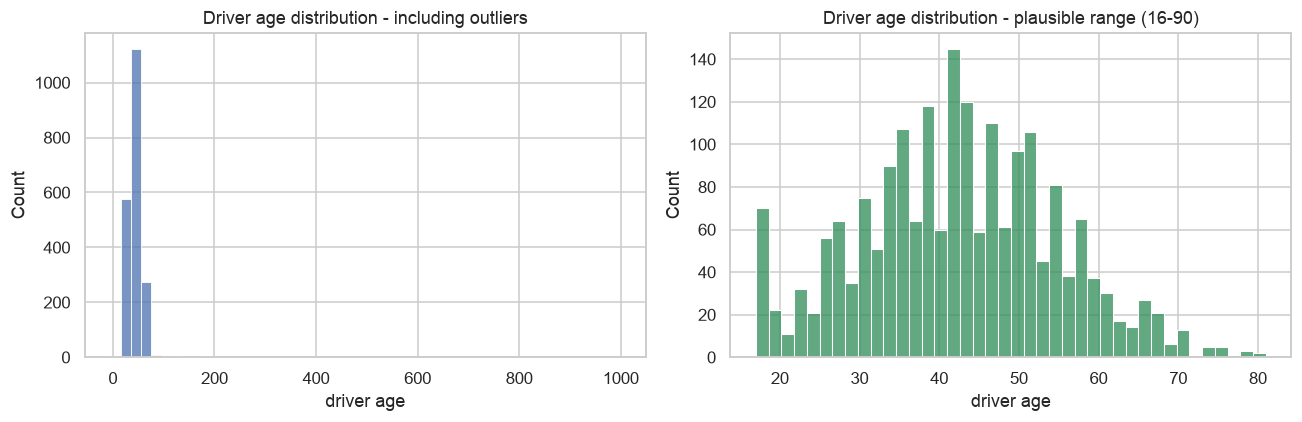

16 values outside 16-90 (0.80%)
[np.int64(-5), np.int64(0), np.int64(12), np.int64(120), np.int64(180), np.int64(999)]


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(claims["driver_age"], bins=50, ax=axes[0])
axes[0].set_title("Driver age distribution - including outliers")
axes[0].set_xlabel("driver age")

plausible = claims[claims["driver_age"].between(16, 90)]
sns.histplot(plausible["driver_age"], bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("Driver age distribution - plausible range (16-90)")
axes[1].set_xlabel("driver age")

plt.tight_layout()
plt.show()

invalid_ages = claims.loc[~claims["driver_age"].between(16, 90), "driver_age"]
print(f"{len(invalid_ages)} values outside 16-90 ({len(invalid_ages) / len(claims):.2%})")
print(sorted(invalid_ages.unique()))

A few distinct error types here: negative/zero values (likely input errors), age 12 (below the legal driving age in Israel), and sentinel-looking values like 120, 180, 999 that were probably meant as "unknown" codes but got entered as numbers. A reasonable valid range is 17-90 (minimum licensing age in Israel is 17).

**Decision:** treat out-of-range values as missing (NaN) and impute with the median driver age, split by `insured_city_type` - this avoids dropping whole claims over one bad field.

**Why this approach:** median is robust to leftover outliers and fits an age variable better than a mean. 
Splitting by `insured_city_type` gives a slightly better estimate than one global value, at low complexity 
cost (only 3 groups). Flagging `driver_age_was_imputed` keeps the imputation visible instead of hiding it.

## Dates – gap between the event and the claim opening

count    2000.000000
mean        6.909500
std         4.396245
min         0.000000
25%         3.000000
50%         7.000000
75%        11.000000
max        14.000000
Name: report_lag_days, dtype: float64
Claims with open_date before event_date: 0


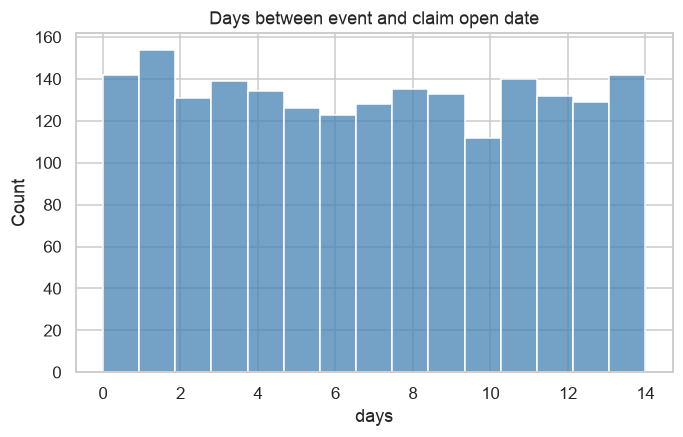

In [27]:
claims["event_date"] = pd.to_datetime(claims["event_date"])
claims["open_date"] = pd.to_datetime(claims["open_date"])
claims["report_lag_days"] = (claims["open_date"] - claims["event_date"]).dt.days

print(claims["report_lag_days"].describe())
print(f"Claims with open_date before event_date: {(claims['report_lag_days'] < 0).sum()}")

plt.figure(figsize=(7, 4))
sns.histplot(claims["report_lag_days"], bins=15, color="steelblue")
plt.title("Days between event and claim open date")
plt.xlabel("days")
plt.show()

No negative values - dates are consistent. The reporting lag (0-14 days, mean ~7) could serve as a proxy for insured urgency/awareness later on, but I won't use it as a feature for the choice model - it's determined *after* the garage was already chosen in practice (leakage risk, since the time to open a claim could be correlated with the process that already involved picking a garage).

## Severity target - `damage_cost_nis`

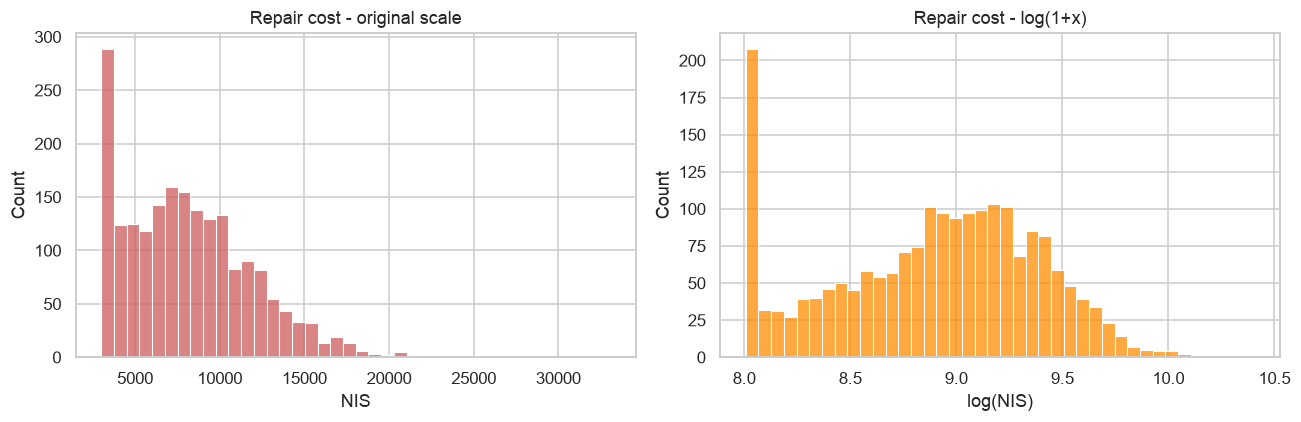

count     2000.000000
mean      8111.998295
std       3840.981039
min       3000.000000
25%       5014.715000
50%       7691.620000
75%      10449.815000
max      33059.470000
Name: damage_cost_nis, dtype: float64

raw skew: 0.83
log skew: -0.25


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(claims["damage_cost_nis"], bins=40, ax=axes[0], color="indianred")
axes[0].set_title("Repair cost - original scale")
axes[0].set_xlabel("NIS")

sns.histplot(np.log1p(claims["damage_cost_nis"]), bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Repair cost - log(1+x)")
axes[1].set_xlabel("log(NIS)")

plt.tight_layout()
plt.show()

print(claims["damage_cost_nis"].describe())
print(f"\nraw skew: {claims['damage_cost_nis'].skew():.2f}")
print(f"log skew: {np.log1p(claims['damage_cost_nis']).skew():.2f}")

Right-skewed as expected for repair costs (most claims are relatively cheap, with a tail of expensive repairs). The log transform noticeably improves symmetry - we'll train the regression target on `log1p(damage_cost_nis)` and invert (`expm1`) for business-facing metrics and interpretation in NIS.

## Repair cost vs. categorical variables

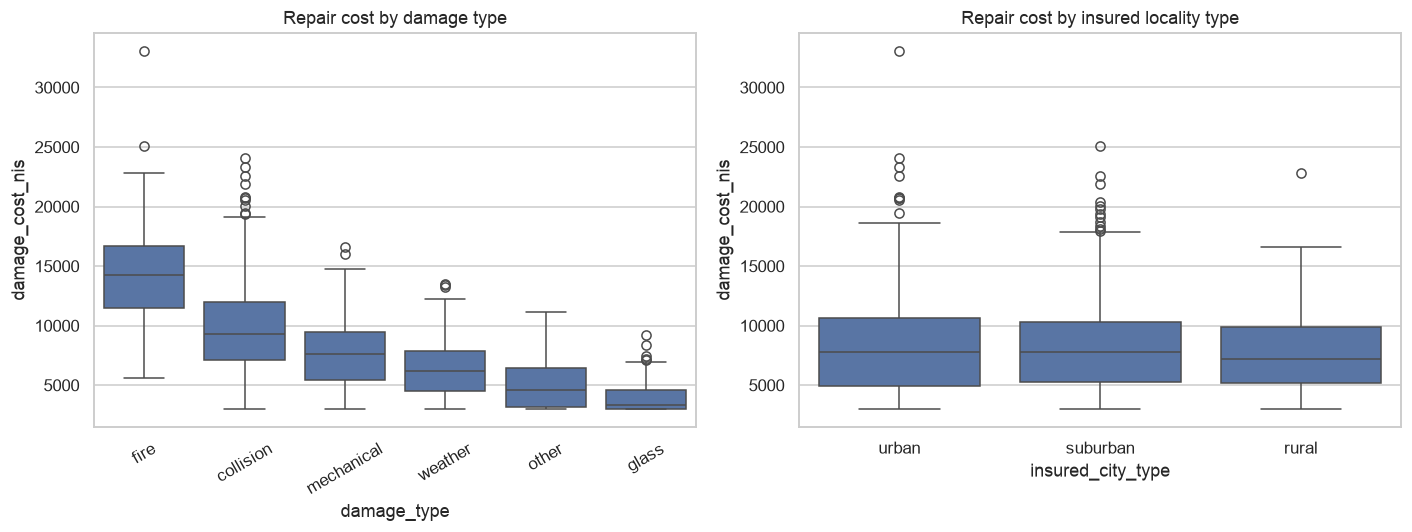

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = claims.groupby("damage_type")["damage_cost_nis"].median().sort_values(ascending=False).index
sns.boxplot(data=claims, x="damage_type", y="damage_cost_nis", order=order, ax=axes[0])
axes[0].set_title("Repair cost by damage type")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=claims, x="insured_city_type", y="damage_cost_nis", ax=axes[1])
axes[1].set_title("Repair cost by insured locality type")

plt.tight_layout()
plt.show()

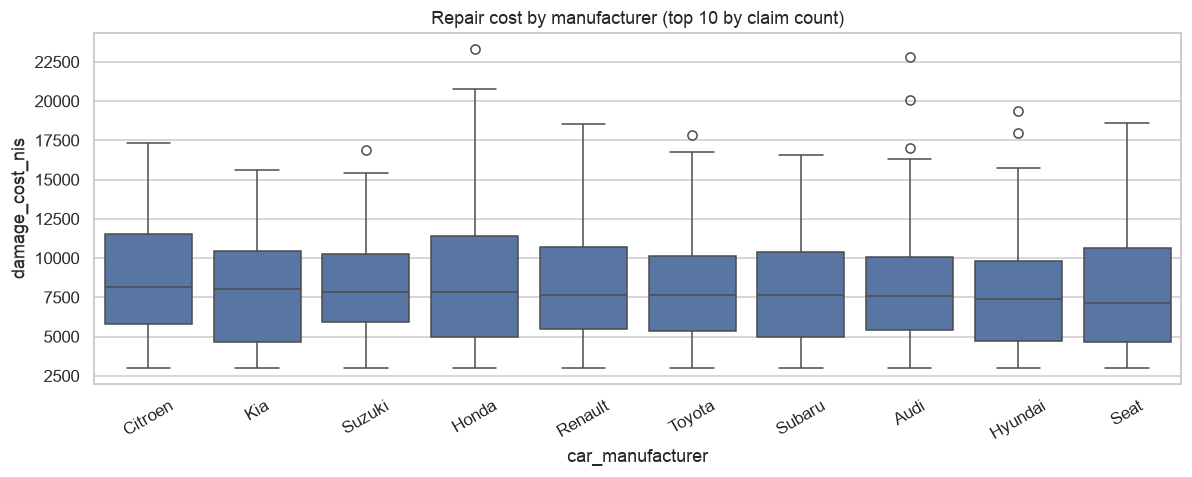

In [30]:
top_manufacturers = claims["car_manufacturer"].value_counts().head(10).index
subset = claims[claims["car_manufacturer"].isin(top_manufacturers)]

plt.figure(figsize=(11, 4.5))
order = subset.groupby("car_manufacturer")["damage_cost_nis"].median().sort_values(ascending=False).index
sns.boxplot(data=subset, x="car_manufacturer", y="damage_cost_nis", order=order)
plt.title("Repair cost by manufacturer (top 10 by claim count)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

`damage_type` shows clear separation between categories (e.g. fire and collision are noticeably pricier than glass) - a good sign it'll be a strong feature for the severity model. Differences across manufacturers and locality types are more subtle, worth revisiting once I add features like vehicle value and age.

## Numeric fields vs. repair cost

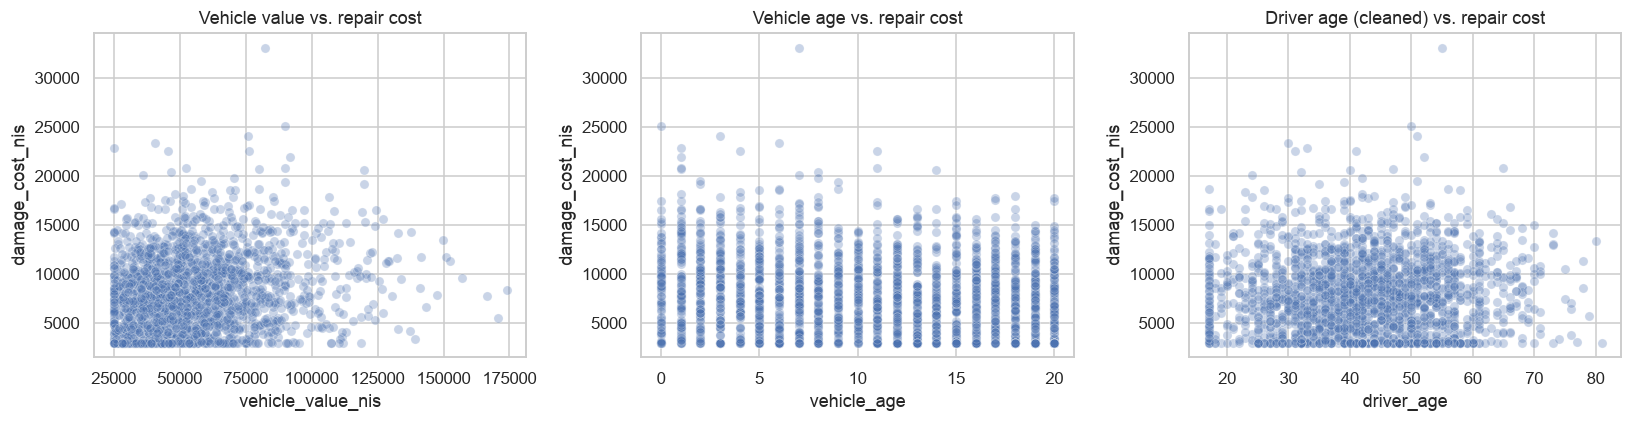

Correlation with damage_cost
vehicle_value_nis    0.174063
vehicle_age         -0.133284
driver_age          -0.008666
damage_cost_nis      1.000000
Name: damage_cost_nis, dtype: float64


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=claims, x="vehicle_value_nis", y="damage_cost_nis", alpha=0.3, ax=axes[0])
axes[0].set_title("Vehicle value vs. repair cost")

sns.scatterplot(data=claims, x="vehicle_age", y="damage_cost_nis", alpha=0.3, ax=axes[1])
axes[1].set_title("Vehicle age vs. repair cost")

clean_age_mask = claims["driver_age"].between(16, 90)
sns.scatterplot(data=claims[clean_age_mask], x="driver_age", y="damage_cost_nis", alpha=0.3, ax=axes[2])
axes[2].set_title("Driver age (cleaned) vs. repair cost")

plt.tight_layout()
plt.show()

print("Correlation with damage_cost")
print(claims[["vehicle_value_nis", "vehicle_age", "driver_age", "damage_cost_nis"]].corr()["damage_cost_nis"])

Vehicle value shows a mild positive correlation with repair cost (makes sense - pricier cars, pricier parts). Vehicle age and driver age don't show a strong linear relationship on their own - there may be more interesting interactions that a non-linear model (GBM) picks up during training.

## Insured-to-garage distance

The choice model will need a distance feature between the insured's location and each candidate garage. I define a haversine function here and take a first look at the distance to the garage actually chosen, as an early sanity check on whether proximity matters for choice.

**Why haversine:** it's the great-circle distance, correcting for the fact that raw 
lat/lon degrees distort with latitude - plain Euclidean distance on coordinates would be misleading. Real 
driving distance would be a better proxy for actual friction, but needs an external routing API per 
claim-garage pair (~200K calls at panel scale) - out of scope here. Haversine is a free, deterministic 
stand-in that tracks driving distance reasonably well, flagged as a v1 with routing distance as a future improvement.

count    1989.000000
mean       16.646233
std        18.057675
min         0.000000
25%         0.000000
50%        11.919508
75%        28.392352
max       109.610033
Name: dist_to_chosen_garage_km, dtype: float64


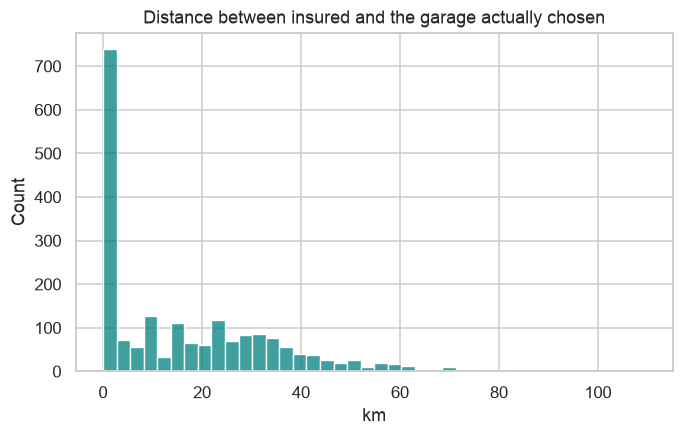

In [32]:
def haversine_km(lat1: np.ndarray, lon1: np.ndarray, lat2: np.ndarray, lon2: np.ndarray) -> np.ndarray:
    """Great-circle distance (km) between two points given lat/lon, vectorized."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


claims_geo = claims.merge(
    garages[["garage_id", "garage_lat", "garage_lon"]],
    left_on="chosen_garage_id", right_on="garage_id", how="left",
)

claims_geo["dist_to_chosen_garage_km"] = haversine_km(
    claims_geo["insured_lat"], claims_geo["insured_lon"],
    claims_geo["garage_lat"], claims_geo["garage_lon"],
)

print(claims_geo["dist_to_chosen_garage_km"].describe())

plt.figure(figsize=(7, 4))
sns.histplot(claims_geo["dist_to_chosen_garage_km"].dropna(), bins=40, color="teal")
plt.title("Distance between insured and the garage actually chosen")
plt.xlabel("km")
plt.show()

Most actual choices are for relatively close garages, with a tail of longer distances. This supports the expected direction - distance should be a meaningful feature in the choice model. We'll examine this more rigorously later, comparing distance to the chosen garage against distance to the other candidates.

## Cleaning functions

Consolidating the cleaning logic worked out above into modular functions we'll reuse in later steps (and in the inference pipeline).

In [33]:
def clean_driver_age(df: pd.DataFrame, min_age: int = 17, max_age: int = 90) -> pd.DataFrame:
    """Replace implausible driver ages with NaN, then impute by median age within locality type.

    Values like -5, 0, 12, 120, 180, 999 are input errors / sentinel values rather than real ages.
    """
    df = df.copy()
    invalid_mask = ~df["driver_age"].between(min_age, max_age)
    df.loc[invalid_mask, "driver_age"] = np.nan

    median_by_city_type = df.groupby("insured_city_type")["driver_age"].transform("median")
    df["driver_age"] = df["driver_age"].fillna(median_by_city_type)
    df["driver_age_was_imputed"] = invalid_mask.astype(int)
    return df


def fill_missing_coordinates(df: pd.DataFrame, lat_col: str, lon_col: str, city_id_col: str) -> pd.DataFrame:
    """Impute missing coordinates using the city's mean lat/lon, and flag which rows were imputed."""
    df = df.copy()
    was_missing = df[lat_col].isnull()

    city_lat = df.groupby(city_id_col)[lat_col].transform("mean")
    city_lon = df.groupby(city_id_col)[lon_col].transform("mean")
    df[lat_col] = df[lat_col].fillna(city_lat)
    df[lon_col] = df[lon_col].fillna(city_lon)

    df[f"{lat_col}_was_imputed"] = was_missing.astype(int)
    return df


def clean_claims(df: pd.DataFrame) -> pd.DataFrame:
    """Full cleaning pipeline for the claims table - wraps the functions above."""
    df = clean_driver_age(df)
    df = fill_missing_coordinates(df, "insured_lat", "insured_lon", "insured_city_id")
    return df

In [34]:
claims_clean = clean_claims(claims)

print(f"Ages imputed: {claims_clean['driver_age_was_imputed'].sum()}")
print(f"Coordinates imputed: {claims_clean['insured_lat_was_imputed'].sum()}")
print(f"Remaining NaN in coordinates: {claims_clean['insured_lat'].isnull().sum()}")
print(f"Driver age range after cleaning: {claims_clean['driver_age'].min()}-{claims_clean['driver_age'].max()}")

Ages imputed: 16
Coordinates imputed: 11
Remaining NaN in coordinates: 0
Driver age range after cleaning: 17.0-81.0


## EDA summary

**Key findings:**
- Full referential integrity across `claims`, `garages` and `potential_garages_by_manufacturer` - no special handling needed for the joins between tables.
- Two sources of data quality issues identified and handled: implausible driver ages (~1%) and missing insured coordinates (~0.5%) - both imputed conservatively (median/mean by locality) with a flag column marking which records were imputed, in case that turns out to be informative.
- `damage_cost_nis` is right-skewed - we'll work in log scale for training the severity model.
- `damage_type` looks like a strong severity feature; geographic distance looks like a strong choice-model feature.